# ### Noteb5
# logistic regression (Amin Sharifi)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Vanilla Baseline Test Accuracy: 0.6667
Vanilla Baseline Test Log-Loss: 0.8609
------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Tuned LR Test Accuracy: 0.6471
Tuned LR Test Log-Loss: 0.8579
World Cup Matches Only - Accuracy: 0.6471 | Log-Loss: 0.8579
              precision    recall  f1-score   support

    Away Win       0.70      0.77      0.73        30
        Draw       0.00      0.00      0.00        24
    Home Win       0.62      0.90      0.74        48

    accuracy                           0.65       102
   macro avg       0.44      0.55      0.49       102
weighted avg       0.50      0.65      0.56       102



C:\Users\shari\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shari\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shari\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

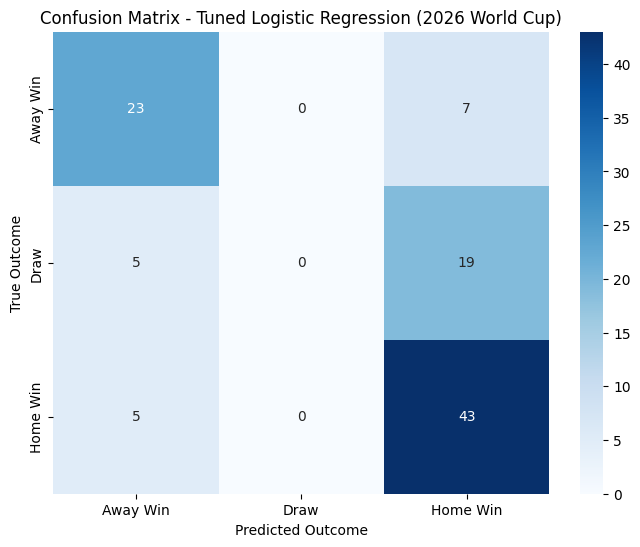

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

# Load data and handle any missing values (NaNs) by filling with 0
X_train = pd.read_csv('../data/Processed/X_train_processed_new.csv').fillna(0)
X_val = pd.read_csv('../data/Processed/X_validation_processed_new.csv').fillna(0)
X_test = pd.read_csv('../data/Processed/X_test_processed_new.csv').fillna(0)

y_train = pd.read_csv('../data/Processed/y_train_new.csv')
y_val = pd.read_csv('../data/Processed/y_validation_new.csv')
y_test = pd.read_csv('../data/Processed/y_test_new.csv')

y_train_encoded = tf.keras.utils.to_categorical(y_train['match_result_encoded'], num_classes=3)
y_val_encoded = tf.keras.utils.to_categorical(y_val['match_result_encoded'], num_classes=3)
y_test_encoded = tf.keras.utils.to_categorical(y_test['match_result_encoded'], num_classes=3)

def build_vanilla_baseline(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(input_dim,)),
        tf.keras.layers.Dense(3, activation='sigmoid') 
    ])
    model.compile(optimizer=tf.keras.optimizers.SGD(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

vanilla_model = build_vanilla_baseline(X_train.shape[1])

vanilla_history = vanilla_model.fit(
    X_train, 
    y_train_encoded,
    epochs=10,
    batch_size=32,
    verbose=0
)

def build_tuned_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(input_dim,)),
        tf.keras.layers.Dense(3, activation='sigmoid') 
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuned_model = build_tuned_model(X_train.shape[1])

tuned_history = tuned_model.fit(
    X_train, 
    y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=50,
    batch_size=32,
    verbose=0
)

raw_vanilla_preds = vanilla_model.predict(X_test)
row_sums_vanilla = raw_vanilla_preds.sum(axis=1, keepdims=True) + 1e-7
norm_vanilla_preds = raw_vanilla_preds / row_sums_vanilla
y_vanilla_classes = np.argmax(norm_vanilla_preds, axis=1)

y_true_classes = y_test['match_result_encoded'].values

vanilla_accuracy = accuracy_score(y_true_classes, y_vanilla_classes)
vanilla_log_loss = log_loss(y_true_classes, norm_vanilla_preds)

print(f"Vanilla Baseline Test Accuracy: {vanilla_accuracy:.4f}")
print(f"Vanilla Baseline Test Log-Loss: {vanilla_log_loss:.4f}")

print("-" * 30)

raw_tuned_preds = tuned_model.predict(X_test)
row_sums_tuned = raw_tuned_preds.sum(axis=1, keepdims=True) + 1e-7
norm_tuned_preds = raw_tuned_preds / row_sums_tuned
y_tuned_classes = np.argmax(norm_tuned_preds, axis=1)

tuned_accuracy = accuracy_score(y_true_classes, y_tuned_classes)
tuned_log_loss = log_loss(y_true_classes, norm_tuned_preds)

print(f"Tuned LR Test Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned LR Test Log-Loss: {tuned_log_loss:.4f}")

if 'cat__is_world_cup_True' in X_test.columns:
    wc_mask = X_test['cat__is_world_cup_True'] == 1.0
    
    wc_preds = norm_tuned_preds[wc_mask]
    wc_true = y_true_classes[wc_mask]
    
    if len(wc_true) > 0:
        wc_acc = accuracy_score(wc_true, np.argmax(wc_preds, axis=1))
        wc_log_loss = log_loss(wc_true, wc_preds)
        print(f"World Cup Matches Only - Accuracy: {wc_acc:.4f} | Log-Loss: {wc_log_loss:.4f}")
    else:
        print("No World Cup matches found in the test set.")
        
    non_wc_preds = norm_tuned_preds[~wc_mask]
    non_wc_true = y_true_classes[~wc_mask]
    
    if len(non_wc_true) > 0:
        non_wc_acc = accuracy_score(non_wc_true, np.argmax(non_wc_preds, axis=1))
        non_wc_log_loss = log_loss(non_wc_true, non_wc_preds)
        print(f"Non-World Cup Matches - Accuracy: {non_wc_acc:.4f} | Log-Loss: {non_wc_log_loss:.4f}")
else:
    print("World Cup indicator column not found in new dataset.")

class_names = ['Away Win', 'Draw', 'Home Win']
print(classification_report(y_true_classes, y_tuned_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_tuned_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tuned Logistic Regression (2026 World Cup)')
plt.ylabel('True Outcome')
plt.xlabel('Predicted Outcome')
plt.show()